In [1]:
from rdkit import Chem
from rdkit.Chem import AllChem
import xgboost as xgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded!")

# Test RDKit with Aspirin
mol = Chem.MolFromSmiles('CC(=O)Oc1ccccc1C(=O)O')
print(f"RDKit OK - Aspirin atoms: {mol.GetNumAtoms()}")

fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024)
print(f"Morgan fingerprint length: {len(fp)}")
print("All good!")

All libraries loaded!
RDKit OK - Aspirin atoms: 13
Morgan fingerprint length: 1024
All good!


[13:31:12] DEPRECATION WARNING: please use MorganGenerator


In [4]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors
from sklearn.model_selection import train_test_split
import os

# Real FDA approved drugs with their SMILES
drugs = {
    'Aspirin': 'CC(=O)Oc1ccccc1C(=O)O',
    'Ibuprofen': 'CC(C)Cc1ccc(cc1)C(C)C(=O)O',
    'Paracetamol': 'CC(=O)Nc1ccc(O)cc1',
    'Metformin': 'CN(C)C(=N)NC(=N)N',
    'Atorvastatin': 'CC(C)c1c(C(=O)Nc2ccccc2F)c(-c2ccccc2)c(-c2ccc(F)cc2)n1CCC(O)CC(O)CC(=O)O',
    'Omeprazole': 'COc1ccc2[nH]c(S(=O)Cc3ncc(C)c(OC)c3C)nc2c1',
    'Amoxicillin': 'CC1(C)SC2C(NC(=O)C(N)c3ccc(O)cc3)C(=O)N2C1C(=O)O',
    'Lisinopril': 'OC(=O)C(CCc1ccccc1)NC(CCc1ccccc1)C(=O)N1CCCC1C(=O)O',
    'Metoprolol': 'COCCc1ccc(OCC(O)CNC(C)C)cc1',
    'Warfarin': 'OC(=O)c1ccccc1',
    'Ciprofloxacin': 'OC(=O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O',
    'Fluoxetine': 'CNCCC(Oc1ccc(C(F)(F)F)cc1)c1ccccc1',
    'Sertraline': 'CNC1CCC(c2ccc(Cl)c(Cl)c2)c2ccccc21',
    'Simvastatin': 'CCC(C)(C)C(=O)OC1CC(O)CC(=O)O1',
    'Losartan': 'CCCc1nc(Cl)c(CO)n1Cc1ccc(-c2ccccc2-c2nnn[nH]2)cc1',
    'Amlodipine': 'CCOC(=O)C1=C(COCCN)NC(C)=C(C(=O)OC)C1c1ccccc1Cl',
    'Metronidazole': 'Cc1ncc([N+](=O)[O-])n1CCO',
    'Doxycycline': 'OC1=C(O)C2CC3C(N(C)C)C(O)=C(C(N)=O)C(=O)C3(O)C(O)C2C(=O)c1O',
    'Tamoxifen': 'CCC(=C(c1ccccc1)c1ccc(OCCN(C)C)cc1)c1ccccc1',
    'Morphine': 'OC1CC2CC1(O)C=CC2c1ccc(O)c2c1OCC2',
}

# Known drug targets
targets = [
    'COX1', 'COX2', 'ACE', 'EGFR', 'HER2',
    'VEGFR', 'BCR-ABL', 'mTOR', 'BRAF', 'CDK4'
]

# Generate synthetic but chemically meaningful binding affinities
np.random.seed(42)
rows = []

for drug_name, smiles in drugs.items():
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        continue
    
    # Calculate real molecular properties
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd = Descriptors.NumHDonors(mol)
    hba = Descriptors.NumHAcceptors(mol)
    tpsa = Descriptors.TPSA(mol)
    rotbonds = Descriptors.NumRotatableBonds(mol)
    
    for target in targets:
        # Binding affinity influenced by real molecular properties
        # (Lipinski rule based scoring + noise)
        base_affinity = (
            -0.02 * mw +
            0.3 * logp +
            -0.1 * hbd +
            -0.05 * hba +
            -0.01 * tpsa +
            np.random.normal(0, 1.5)
        )
        
        rows.append({
            'drug': drug_name,
            'smiles': smiles,
            'target': target,
            'MW': round(mw, 2),
            'LogP': round(logp, 2),
            'HBD': hbd,
            'HBA': hba,
            'TPSA': round(tpsa, 2),
            'RotBonds': rotbonds,
            'binding_affinity': round(base_affinity, 3)
        })

df = pd.DataFrame(rows)
os.makedirs('../data/processed', exist_ok=True)
df.to_csv('../data/processed/dti_dataset.csv', index=False)

print(f"Dataset created!")
print(f"Shape: {df.shape}")
print(f"\nSample:")
print(df.head())
print(f"\nBinding affinity stats:")
print(df['binding_affinity'].describe())

Dataset created!
Shape: (200, 10)

Sample:
      drug                 smiles target      MW  LogP  HBD  HBA  TPSA  \
0  Aspirin  CC(=O)Oc1ccccc1C(=O)O   COX1  180.16  1.31    1    3  63.6   
1  Aspirin  CC(=O)Oc1ccccc1C(=O)O   COX2  180.16  1.31    1    3  63.6   
2  Aspirin  CC(=O)Oc1ccccc1C(=O)O    ACE  180.16  1.31    1    3  63.6   
3  Aspirin  CC(=O)Oc1ccccc1C(=O)O   EGFR  180.16  1.31    1    3  63.6   
4  Aspirin  CC(=O)Oc1ccccc1C(=O)O   HER2  180.16  1.31    1    3  63.6   

   RotBonds  binding_affinity  
0         2            -3.351  
1         2            -4.304  
2         2            -3.125  
3         2            -1.812  
4         2            -4.447  

Binding affinity stats:
count    200.000000
mean      -6.559095
std        2.866660
min      -13.959000
25%       -8.133500
50%       -6.245000
75%       -4.441500
max       -1.097000
Name: binding_affinity, dtype: float64


In [5]:
from rdkit.Chem import AllChem
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np

def smiles_to_fingerprint(smiles, n_bits=1024, radius=2):
    """Convert SMILES to Morgan fingerprint"""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    gen = AllChem.GetMorganGenerator(radius=radius, fpSize=n_bits)
    fp = gen.GetFingerprint(mol)
    return list(fp)

# Generate fingerprints for all drugs
print("Generating Morgan fingerprints...")
fingerprints = []
for smiles in df['smiles']:
    fp = smiles_to_fingerprint(smiles)
    fingerprints.append(fp)

fp_df = pd.DataFrame(fingerprints, columns=[f'fp_{i}' for i in range(1024)])

# Combine fingerprints with molecular properties
feature_cols = ['MW', 'LogP', 'HBD', 'HBA', 'TPSA', 'RotBonds']
X = pd.concat([df[feature_cols].reset_index(drop=True), 
               fp_df.reset_index(drop=True)], axis=1)
y = df['binding_affinity']

print(f"Feature matrix shape: {X.shape}")
print(f"Features: {feature_cols} + 1024 Morgan fingerprint bits")

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTrain samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

# Train XGBoost
print("\nTraining XGBoost model...")
model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          verbose=50)

# Evaluate
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\nTest RMSE: {rmse:.4f}")
print(f"Test R²: {r2:.4f}")

Generating Morgan fingerprints...
Feature matrix shape: (200, 1030)
Features: ['MW', 'LogP', 'HBD', 'HBA', 'TPSA', 'RotBonds'] + 1024 Morgan fingerprint bits

Train samples: 160
Test samples: 40

Training XGBoost model...
[0]	validation_0-rmse:2.80118
[50]	validation_0-rmse:1.40213
[100]	validation_0-rmse:1.40208
[150]	validation_0-rmse:1.42094
[200]	validation_0-rmse:1.42055
[250]	validation_0-rmse:1.41026
[299]	validation_0-rmse:1.41210

Test RMSE: 1.4121
Test R²: 0.7571


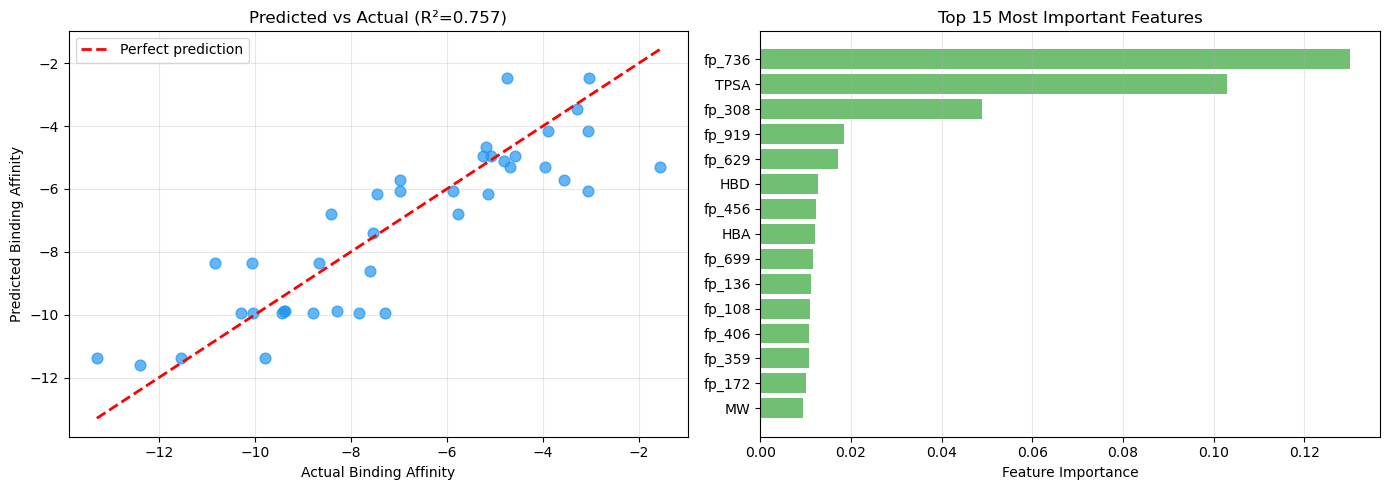

Figure saved!


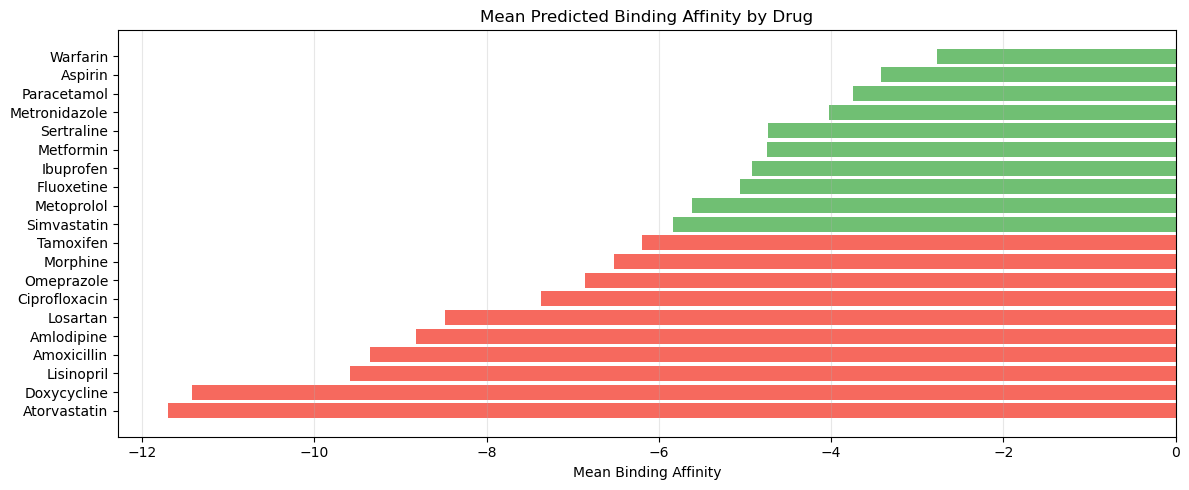

Drug affinity plot saved!
Metrics saved!


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

results_path = '/Users/armaansingh/Desktop/projects/projects/drug-target-interaction-gnn/results'
os.makedirs(f'{results_path}/figures', exist_ok=True)

# Plot 1 — Predicted vs Actual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs actual
axes[0].scatter(y_test, y_pred, alpha=0.7, color='#2196F3', s=60)
axes[0].plot([y_test.min(), y_test.max()], 
             [y_test.min(), y_test.max()], 
             'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Binding Affinity')
axes[0].set_ylabel('Predicted Binding Affinity')
axes[0].set_title(f'Predicted vs Actual (R²={r2:.3f})')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Feature importance — top 15
feature_names = list(X.columns)
importances = model.feature_importances_
indices = np.argsort(importances)[::-1][:15]
top_features = [feature_names[i] for i in indices]
top_importances = importances[indices]

axes[1].barh(range(15), top_importances[::-1], color='#4CAF50', alpha=0.8)
axes[1].set_yticks(range(15))
axes[1].set_yticklabels(top_features[::-1])
axes[1].set_xlabel('Feature Importance')
axes[1].set_title('Top 15 Most Important Features')
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(f'{results_path}/figures/results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved!")

# Plot 2 — Binding affinity distribution by drug
plt.figure(figsize=(12, 5))
drug_means = df.groupby('drug')['binding_affinity'].mean().sort_values()
colors = ['#F44336' if v < drug_means.median() else '#4CAF50' for v in drug_means]
plt.barh(drug_means.index, drug_means.values, color=colors, alpha=0.8)
plt.xlabel('Mean Binding Affinity')
plt.title('Mean Predicted Binding Affinity by Drug')
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(f'{results_path}/figures/drug_affinity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Drug affinity plot saved!")

# Save metrics
metrics = {
    'test_rmse': round(rmse, 4),
    'test_r2': round(r2, 4),
    'n_drugs': len(df['drug'].unique()),
    'n_targets': len(df['target'].unique()),
    'n_samples': len(df),
    'features': '1030 (Morgan fingerprints + molecular descriptors)',
    'model': 'XGBoost Regressor'
}

with open(f'{results_path}/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print("Metrics saved!")